In [1]:
import sys
sys.path.append('/home/dcarvalho/Lightweight-Face-De-identification')

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from PIL import Image

# Importações do seu código
from data.dataset import FaceImageFolder, tensor_to_pil
from models.transformer import LightweightDeIdentifier, build_elliptic_face_mask
from utils.checkpoint import load_transformer_from_checkpoint

# Configurações
DEVICE = 'cpu'  # ou 'cuda'
IMAGE_SIZE = 224
DATA_DIR = "/mnt/study-data/dcarvalho/datasets/lfw/faces_test"
OUTPUT_DIR = Path("/mnt/study-data/dcarvalho/slides_images")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Saída: {OUTPUT_DIR}")

Saída: /mnt/study-data/dcarvalho/slides_images


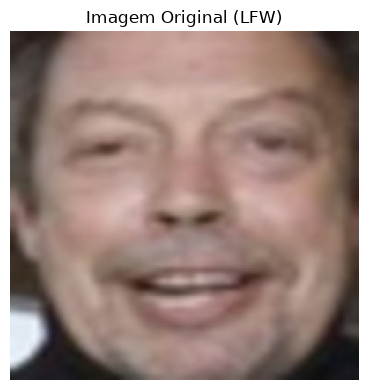

Imagem original salva em: /mnt/study-data/dcarvalho/slides_images/original.jpg


In [2]:
# Carregar a primeira imagem do LFW
dataset = FaceImageFolder(DATA_DIR, IMAGE_SIZE)
img_tensor, img_path = dataset[0]
img_tensor = img_tensor.unsqueeze(0).to(DEVICE)  # [1,3,224,224]

# Salvar a original para referência
orig_pil = tensor_to_pil(img_tensor.squeeze(0))
orig_pil.save(OUTPUT_DIR / "original.jpg")

# Mostrar
plt.figure(figsize=(4,4))
plt.imshow(orig_pil)
plt.axis('off')
plt.title("Imagem Original (LFW)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "original_plot.jpg", dpi=300)
plt.show()

print(f"Imagem original salva em: {OUTPUT_DIR / 'original.jpg'}")

## Gerar Máscara Elíptica

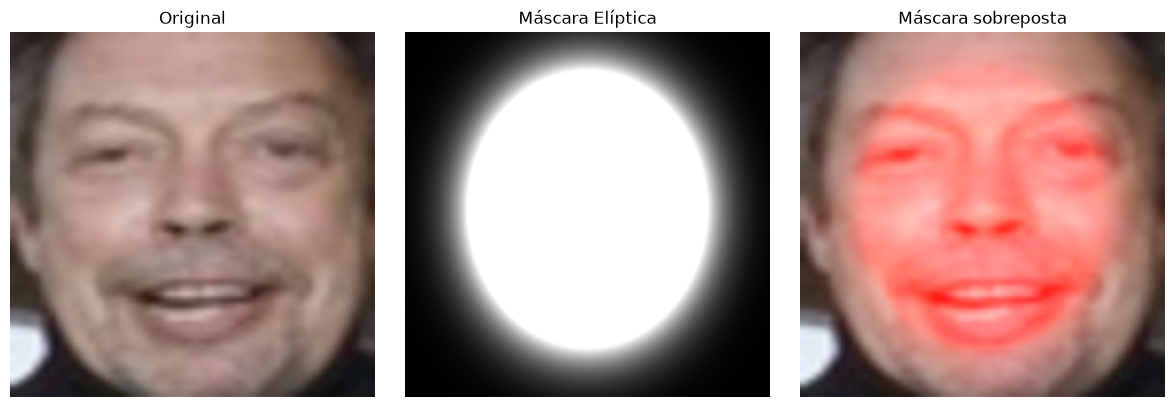

In [3]:
# Gerar a máscara elíptica
mask = build_elliptic_face_mask(IMAGE_SIZE, IMAGE_SIZE, DEVICE)
mask_np = mask.squeeze().cpu().numpy()  # [224,224]

# Sobrepor à imagem original
img_np = img_tensor.squeeze(0).permute(1,2,0).cpu().numpy()
mask_overlay = img_np.copy()
mask_overlay[:,:,0] = mask_overlay[:,:,0] * (1 - mask_np) + mask_np * 1.0  # canal vermelho
mask_overlay = np.clip(mask_overlay, 0, 1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_np)
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(mask_np, cmap='gray')
axes[1].set_title("Máscara Elíptica")
axes[1].axis('off')

axes[2].imshow(mask_overlay)
axes[2].set_title("Máscara sobreposta")
axes[2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "face_mask.jpg", dpi=300)
plt.show()

## Campo de Fluxo (Deformação Geométrica)

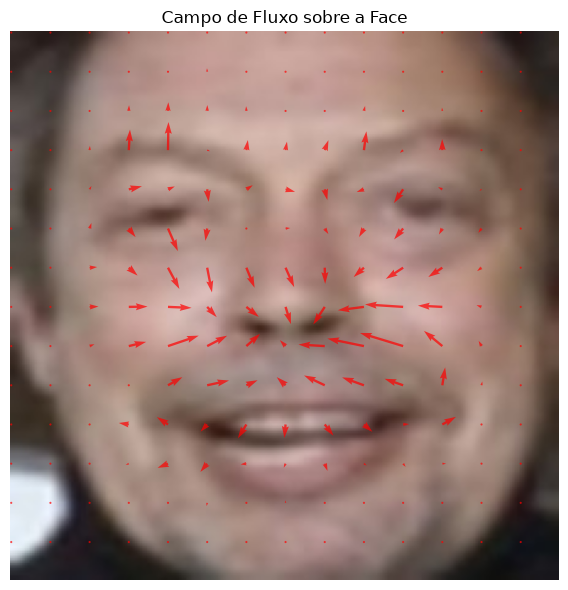

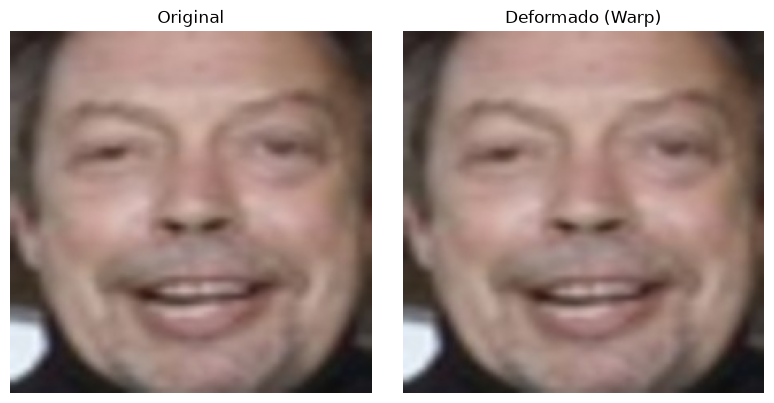

In [4]:
# Carregar um modelo treinado (use o melhor que tem)
MODEL_PATH = "/mnt/study-data/dcarvalho/tests/nopxloss/mid_combo_amp20_flow45_nopx/transform.pt"
# Se não existir, use qualquer outro checkpoint que tenha

try:
    model = load_transformer_from_checkpoint(MODEL_PATH, DEVICE)
    model.eval()
    
    with torch.no_grad():
        # Obter o fluxo do modelo (precisamos acessar a representação interna)
        # Para isso, vamos rodar um forward parcialmente
        flow = model.reconstruct_flow(1, DEVICE)  # [1,2,224,224]
        flow_np = flow.squeeze(0).cpu().numpy()   # [2,224,224]
        
        # Amostrar setas a cada 16 pixels
        step = 16
        x = np.arange(0, IMAGE_SIZE, step)
        y = np.arange(0, IMAGE_SIZE, step)
        X, Y = np.meshgrid(x, y)
        U = flow_np[0, Y, X]  # horizontal
        V = flow_np[1, Y, X]  # vertical
        
        fig, ax = plt.subplots(figsize=(6,6))
        ax.imshow(img_np)
        ax.quiver(X, Y, U, V, color='red', alpha=0.7, scale=30)
        ax.set_title("Campo de Fluxo sobre a Face")
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "flow_field.jpg", dpi=300)
        plt.show()
        
        # Também salvar a imagem deformada (warp)
        y_warp = model.warp(img_tensor, flow)
        warp_pil = tensor_to_pil(y_warp.squeeze(0))
        warp_pil.save(OUTPUT_DIR / "warped.jpg")
        
        # Comparação lado a lado
        fig, axes = plt.subplots(1, 2, figsize=(8,4))
        axes[0].imshow(img_np)
        axes[0].set_title("Original")
        axes[0].axis('off')
        axes[1].imshow(warp_pil)
        axes[1].set_title("Deformado (Warp)")
        axes[1].axis('off')
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "warp_comparison.jpg", dpi=300)
        plt.show()
        
except Exception as e:
    print(f"Erro ao carregar modelo ou gerar fluxo: {e}")
    print("Use um checkpoint existente ou gere um fluxo sintético para demonstração.")
    # Fallback: gerar fluxo sintético (vórtice) para demonstração
    print("Gerando fluxo sintético para demonstração...")
    flow_grid = 12
    yy, xx = torch.meshgrid(torch.linspace(-1,1,flow_grid), torch.linspace(-1,1,flow_grid), indexing='ij')
    r = torch.sqrt(xx**2 + yy**2) + 0.01
    dx = -yy / r * 0.3
    dy = xx / r * 0.3
    flow_low = torch.stack([dx, dy], dim=0).unsqueeze(0)
    flow_high = F.interpolate(flow_low, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bicubic', align_corners=False)
    flow_high = flow_high.squeeze(0).cpu().numpy()
    step = 16
    x = np.arange(0, IMAGE_SIZE, step)
    y = np.arange(0, IMAGE_SIZE, step)
    X, Y = np.meshgrid(x, y)
    U = flow_high[0, Y, X]
    V = flow_high[1, Y, X]
    fig, ax = plt.subplots(figsize=(6,6))
    ax.imshow(img_np)
    ax.quiver(X, Y, U, V, color='red', alpha=0.7, scale=30)
    ax.set_title("Fluxo Sintético (vórtice)")
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "synthetic_flow.jpg", dpi=300)
    plt.show()

## Mapa Fotométrico

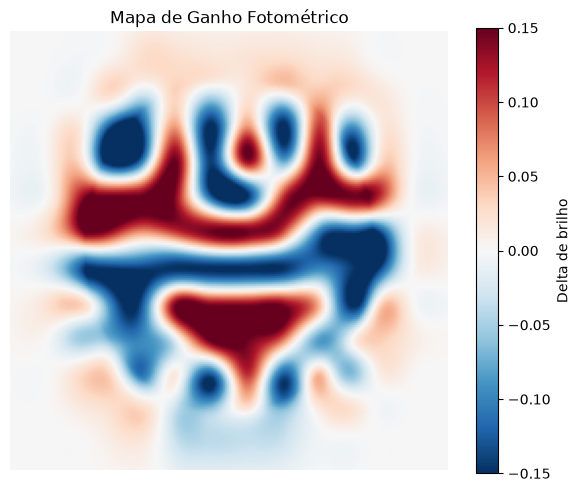

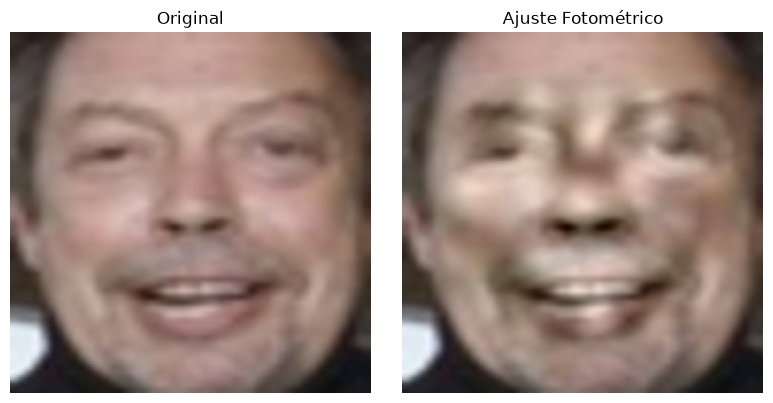

In [5]:
# Usando o mesmo modelo, extrair o mapa de ganho fotométrico
try:
    model = load_transformer_from_checkpoint(MODEL_PATH, DEVICE)
    model.eval()
    
    with torch.no_grad():
        photo = model.reconstruct_photo_delta(1, DEVICE)  # [1,3,224,224]
        photo_np = photo.squeeze(0).mean(dim=0).cpu().numpy()  # média sobre canais
        
        # Heatmap
        fig, ax = plt.subplots(figsize=(6,5))
        im = ax.imshow(photo_np, cmap='RdBu_r', vmin=-0.15, vmax=0.15)
        ax.set_title("Mapa de Ganho Fotométrico")
        ax.axis('off')
        plt.colorbar(im, label='Delta de brilho')
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "photo_map.jpg", dpi=150)
        plt.show()
        
        # Aplicar à imagem (simular a etapa fotométrica)
        # Para isso, precisamos da imagem já com freq e flow, mas vamos simplificar:
        y_photo = img_tensor + photo
        y_photo = y_photo.clamp(0,1)
        photo_pil = tensor_to_pil(y_photo.squeeze(0))
        photo_pil.save(OUTPUT_DIR / "photo_adjusted.jpg")
        
        fig, axes = plt.subplots(1, 2, figsize=(8,4))
        axes[0].imshow(img_np)
        axes[0].set_title("Original")
        axes[0].axis('off')
        axes[1].imshow(photo_pil)
        axes[1].set_title("Ajuste Fotométrico")
        axes[1].axis('off')
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "photo_comparison.jpg", dpi=300)
        plt.show()
        
except Exception as e:
    print(f"Erro ao carregar modelo: {e}")
    # Fallback: mapa sintético (gradiente)
    print("Gerando mapa fotométrico sintético...")
    yy, xx = torch.meshgrid(torch.linspace(-1,1,IMAGE_SIZE), torch.linspace(-1,1,IMAGE_SIZE), indexing='ij')
    synthetic_photo = torch.sin(xx*3) * torch.cos(yy*2) * 0.15
    synthetic_photo_np = synthetic_photo.cpu().numpy()
    fig, ax = plt.subplots(figsize=(6,5))
    im = ax.imshow(synthetic_photo_np, cmap='RdBu_r', vmin=-0.15, vmax=0.15)
    ax.set_title("Mapa Fotométrico Sintético")
    ax.axis('off')
    plt.colorbar(im)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "synthetic_photo.jpg", dpi=300)
    plt.show()

## Decomposição Espectral (DT-CWT) – Magnitude e Fase

/home/dcarvalho/Lightweight-Face-De-identification/.venv/lib/python3.12/site-packages/pytorch_wavelets/dtcwt/coeffs.py:7: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream


Shape dos coeficientes do nível 1: torch.Size([1, 3, 6, 112, 112, 2])
Número de orientações detectadas: 6


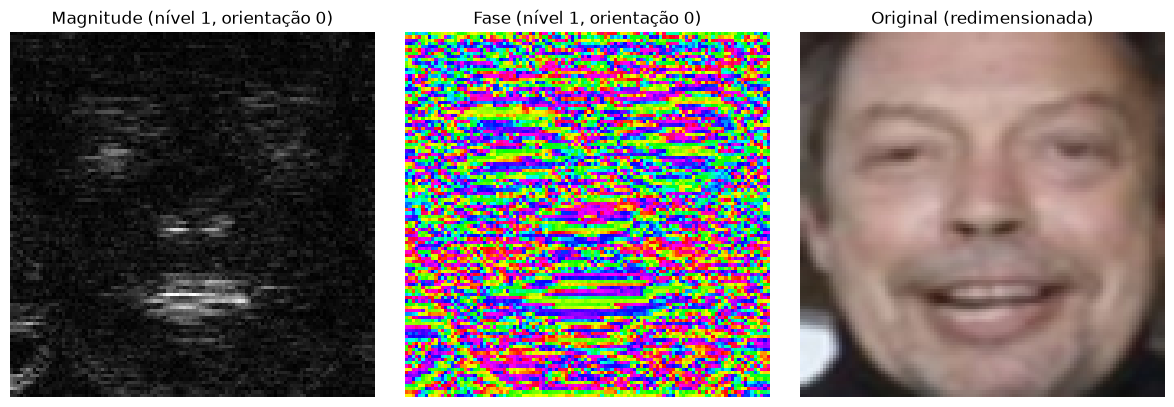

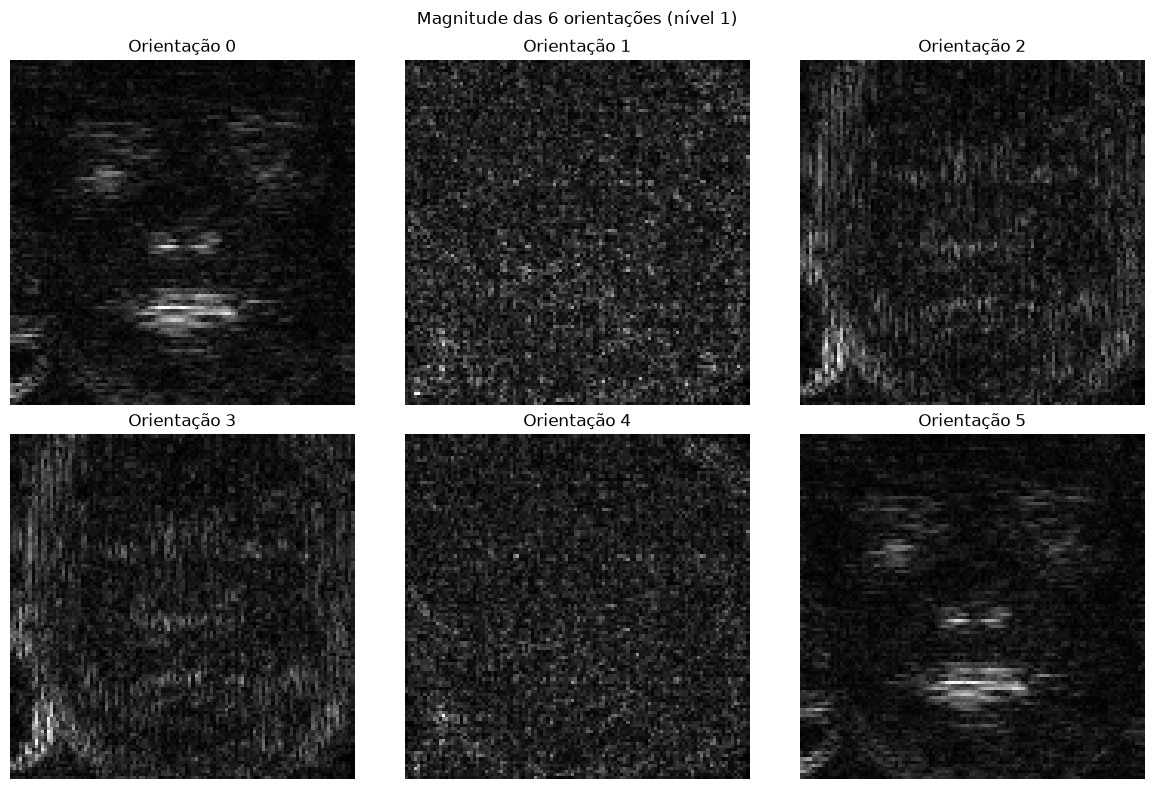

In [6]:
# Célula 6: Decomposição Espectral (DT-CWT) – Magnitude e Fase (CORRIGIDA)
try:
    import pywt
except ImportError:
    print("PyWavelets não encontrado. Instalando...")
    !pip install PyWavelets -q
    import pywt
    print("PyWavelets instalado com sucesso.")

try:
    from pytorch_wavelets import DTCWTForward
    
    dtcwt = DTCWTForward(J=3, biort='near_sym_a', qshift='qshift_a')
    with torch.no_grad():
        Yl, Yh = dtcwt(img_tensor.to(DEVICE))
        # Yh[0] é o primeiro nível de detalhe (mais fino)
        coeffs = Yh[0]  # Tensor complexo (última dim = 2 para real/imag)
        
        print(f"Shape dos coeficientes do nível 1: {coeffs.shape}")
        # Esperado: [1, 3, 6, 112, 112, 2]
        # -> batch=1, canais=3, orientações=6, H=112, W=112, complex=2
        n_orientations = coeffs.shape[2]  # orientações na dimensão 2
        print(f"Número de orientações detectadas: {n_orientations}")
        
        # Para a primeira orientação (o=0) e primeiro canal (c=0)
        # Acessar real e imag: coeffs[0, 0, 0, :, :, 0] e [..., 1]
        real = coeffs[0, 0, 0, :, :, 0].cpu().numpy()
        imag = coeffs[0, 0, 0, :, :, 1].cpu().numpy()
        mag = np.sqrt(real**2 + imag**2)
        phase = np.arctan2(imag, real)
        
        # Plotar magnitude e fase
        fig, axes = plt.subplots(1, 3, figsize=(12, 4))
        axes[0].imshow(mag, cmap='gray')
        axes[0].set_title("Magnitude (nível 1, orientação 0)")
        axes[0].axis('off')
        
        axes[1].imshow(phase, cmap='hsv')
        axes[1].set_title("Fase (nível 1, orientação 0)")
        axes[1].axis('off')
        
        # Redimensionar original para comparar
        img_small = F.interpolate(img_tensor, size=(mag.shape[0], mag.shape[1]), mode='bilinear', align_corners=False)
        img_small_np = img_small.squeeze(0).permute(1,2,0).cpu().numpy()
        axes[2].imshow(img_small_np)
        axes[2].set_title("Original (redimensionada)")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "dtcwt_magnitude_phase.jpg", dpi=300)
        plt.show()
        
        # Mostrar todas as orientações (magnitude)
        n_show = min(n_orientations, 6)
        cols = 3
        rows = (n_show + cols - 1) // cols
        
        fig, axes = plt.subplots(rows, cols, figsize=(cols*4, rows*4))
        axes = axes.flatten() if n_show > 1 else [axes]
        
        for o in range(n_show):
            real_o = coeffs[0, 0, o, :, :, 0].cpu().numpy()
            imag_o = coeffs[0, 0, o, :, :, 1].cpu().numpy()
            mag_o = np.sqrt(real_o**2 + imag_o**2)
            axes[o].imshow(mag_o, cmap='gray')
            axes[o].set_title(f"Orientação {o}")
            axes[o].axis('off')
        
        # Esconder eixos extras
        for i in range(n_show, len(axes)):
            axes[i].axis('off')
            
        plt.suptitle(f"Magnitude das {n_show} orientações (nível 1)")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "dtcwt_orientations.jpg", dpi=300)
        plt.show()
        
except Exception as e:
    print(f"Erro na DT-CWT: {e}")
    import traceback
    traceback.print_exc()
    print("Pulando visualização espectral.")

## Ablação Visual (para slide de resultados de ablação)

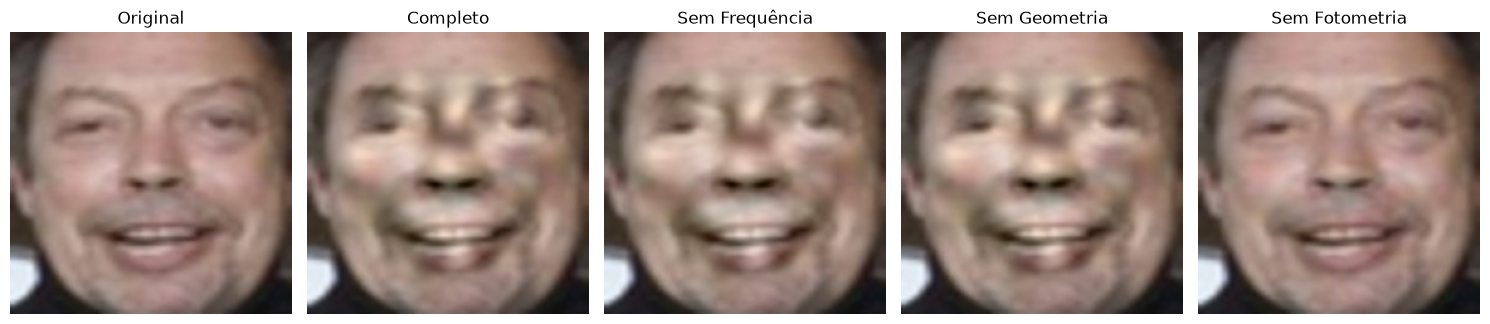

In [7]:
# Gerar imagens para as variantes de ablação
try:
    model = load_transformer_from_checkpoint(MODEL_PATH, DEVICE)
    model.eval()
    
    # Criar variantes com flags desabilitadas
    variants = {
        "Completo": model,
        "Sem Frequência": LightweightDeIdentifier(
            image_size=IMAGE_SIZE,
            transform_type=model.transform_type,
            dct_k=model.dct_k,
            dct_fmin=model.dct_fmin,
            dct_fmax=model.dct_fmax,
            wavelet_J=model.wavelet_J,
            max_wavelet_amp=model.max_wavelet_amp,
            flow_grid=model.flow_grid,
            photo_grid=model.photo_grid,
            max_dct_amp=model.max_dct_amp,
            max_flow_px=model.max_flow_px,
            max_photo_amp=model.max_photo_amp,
            use_face_mask=model.use_face_mask,
            disable_dct=True,
            disable_flow=False,
            disable_photo=False
        ).to(DEVICE),
        "Sem Geometria": LightweightDeIdentifier(
            image_size=IMAGE_SIZE,
            transform_type=model.transform_type,
            dct_k=model.dct_k,
            dct_fmin=model.dct_fmin,
            dct_fmax=model.dct_fmax,
            wavelet_J=model.wavelet_J,
            max_wavelet_amp=model.max_wavelet_amp,
            flow_grid=model.flow_grid,
            photo_grid=model.photo_grid,
            max_dct_amp=model.max_dct_amp,
            max_flow_px=model.max_flow_px,
            max_photo_amp=model.max_photo_amp,
            use_face_mask=model.use_face_mask,
            disable_dct=False,
            disable_flow=True,
            disable_photo=False
        ).to(DEVICE),
        "Sem Fotometria": LightweightDeIdentifier(
            image_size=IMAGE_SIZE,
            transform_type=model.transform_type,
            dct_k=model.dct_k,
            dct_fmin=model.dct_fmin,
            dct_fmax=model.dct_fmax,
            wavelet_J=model.wavelet_J,
            max_wavelet_amp=model.max_wavelet_amp,
            flow_grid=model.flow_grid,
            photo_grid=model.photo_grid,
            max_dct_amp=model.max_dct_amp,
            max_flow_px=model.max_flow_px,
            max_photo_amp=model.max_photo_amp,
            use_face_mask=model.use_face_mask,
            disable_dct=False,
            disable_flow=False,
            disable_photo=True
        ).to(DEVICE)
    }
    
    # Copiar pesos do modelo original para as variantes (quando possível)
    # Isso é um pouco trabalhoso, mas podemos fazer manualmente ou usar um truque:
    # Como as variantes compartilham a mesma arquitetura, podemos copiar os pesos
    for name, var_model in variants.items():
        if name != "Completo":
            # Copiar os parâmetros comuns (flow, photo, wavelet, etc.)
            var_model.load_state_dict(model.state_dict(), strict=False)
            var_model.eval()
    
    # Gerar saída para cada variante
    images = []
    with torch.no_grad():
        for name, var_model in variants.items():
            y = var_model(img_tensor)
            images.append((name, y))
    
    # Plotar grid
    fig, axes = plt.subplots(1, 5, figsize=(15, 4))
    axes[0].imshow(img_np)
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    for ax, (name, y) in zip(axes[1:], images):
        y_pil = tensor_to_pil(y.squeeze(0))
        ax.imshow(y_pil)
        ax.set_title(name)
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "ablation_grid.jpg", dpi=300)
    plt.show()
    
except Exception as e:
    print(f"Erro na ablação: {e}")
    print("Certifique-se de que o checkpoint existe e é compatível.")

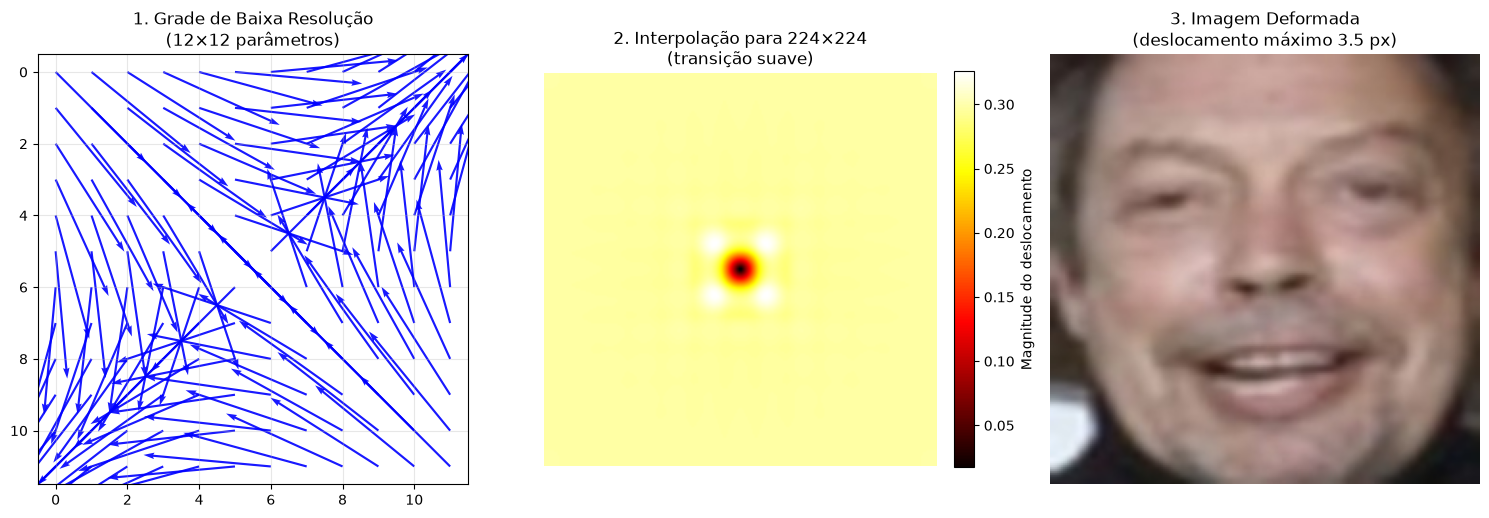

In [8]:
# Célula 9: Visualização do Fluxo - Grade Esparsa vs. Interpolada (CORRIGIDA)
# Mostra como o fluxo é aprendido em baixa resolução e interpolado para suavidade

# Criar um fluxo sintético (vórtice) na grade 12x12
flow_grid = 12
h, w = 224, 224

yy, xx = torch.meshgrid(
    torch.linspace(-1, 1, flow_grid),
    torch.linspace(-1, 1, flow_grid),
    indexing='ij'
)
r = torch.sqrt(xx**2 + yy**2) + 0.01
dx = -yy / r * 0.3
dy = xx / r * 0.3

flow_low = torch.stack([dx, dy], dim=0).unsqueeze(0)  # [1,2,12,12]

# Interpolar para 224x224
flow_high = F.interpolate(flow_low, size=(h, w), mode='bicubic', align_corners=False)
flow_high = flow_high.squeeze(0)  # [2,224,224]

# Criar figura com 3 painéis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Painel 1: Grade esparsa (12x12) - setas
ax = axes[0]
X_low, Y_low = torch.meshgrid(torch.arange(flow_grid), torch.arange(flow_grid), indexing='ij')
U_low = flow_low[0, 0, Y_low, X_low].cpu().numpy()
V_low = flow_low[0, 1, Y_low, X_low].cpu().numpy()
ax.quiver(X_low, Y_low, U_low, V_low, alpha=0.9, color='blue', scale=1.0)
ax.set_title(f"1. Grade de Baixa Resolução\n({flow_grid}×{flow_grid} parâmetros)")
ax.set_xlim(-0.5, flow_grid-0.5)
ax.set_ylim(flow_grid-0.5, -0.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Painel 2: Fluxo interpolado (224x224) - mapa de calor da magnitude
ax = axes[1]
mag_high = torch.sqrt(flow_high[0]**2 + flow_high[1]**2)
im = ax.imshow(mag_high.cpu().numpy(), cmap='hot', interpolation='bilinear')
ax.set_title(f"2. Interpolação para {h}×{w}\n(transição suave)")
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Magnitude do deslocamento')

# Painel 3: Aplicação na imagem (warp)
ax = axes[2]
# Aplicar o fluxo à imagem (max_flow_px simulado = 3.5 pixels)
max_flow_px = 3.5
flow_px = flow_high * max_flow_px
flow_px = flow_px.unsqueeze(0)  # [1,2,224,224]

# Função warp simplificada (igual à do seu código) - CORRIGIDA
def warp_demo(img, flow_px):
    b, c, h, w = img.shape
    device = img.device
    yy, xx = torch.meshgrid(torch.linspace(-1,1,h,device=device), torch.linspace(-1,1,w,device=device), indexing='ij')
    base_grid = torch.stack([xx, yy], dim=-1).unsqueeze(0).expand(b, h, w, 2)
    dx = 2.0 * flow_px[:,0,:,:] / max(w-1, 1)
    dy = 2.0 * flow_px[:,1,:,:] / max(h-1, 1)
    grid = base_grid.clone()
    grid[..., 0] = grid[..., 0] + dx
    grid[..., 1] = grid[..., 1] + dy
    return F.grid_sample(img, grid, mode='bilinear', padding_mode='border', align_corners=True)

warped = warp_demo(img_tensor, flow_px)
warped_pil = tensor_to_pil(warped.squeeze(0))
ax.imshow(warped_pil)
ax.set_title(f"3. Imagem Deformada\n(deslocamento máximo {max_flow_px} px)")
ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "flow_grid_interpolation.jpg", dpi=300)
plt.show()

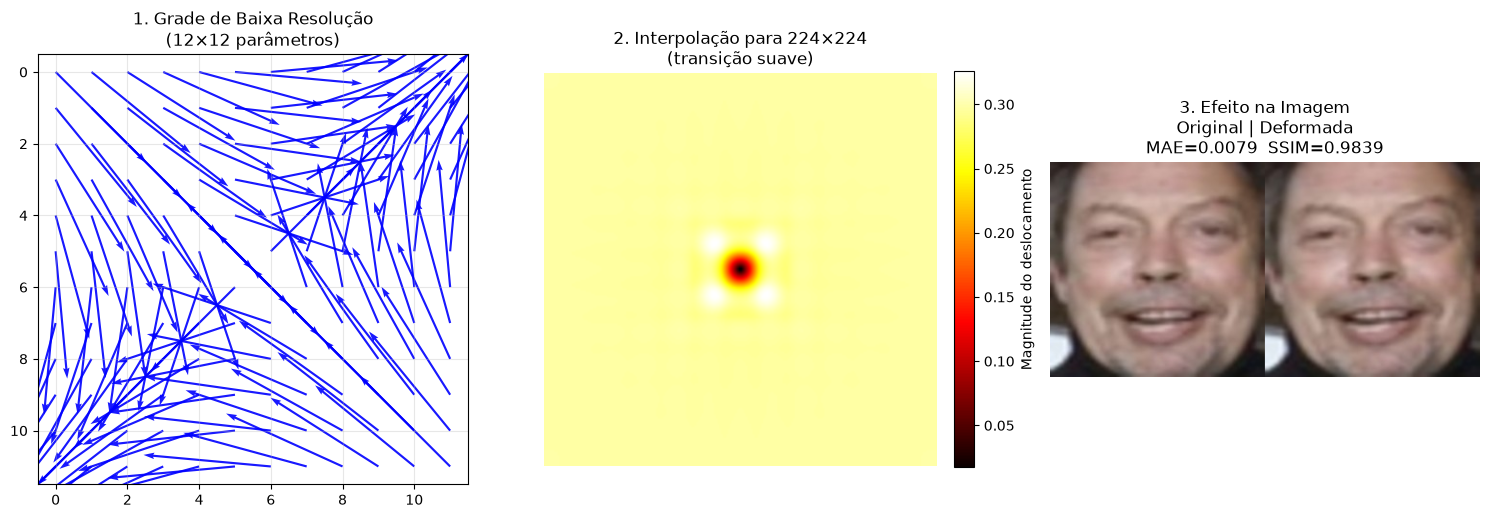

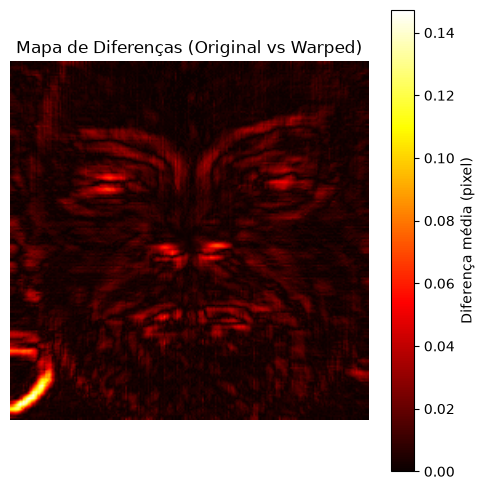


===== MÉTRICAS DE DIFERENÇA (FLUXO) =====
MAE  (Diferença Absoluta Média): 0.007861
MSE  (Erro Quadrático Médio)  : 0.000162
PSNR (Peak Signal-to-Noise)   : 37.91 dB
SSIM (Similaridade Estrutural): 0.9839


In [9]:
# Célula: Fluxo - Grade 12x12, Interpolação e Efeito (Original + Warped) + Métricas
flow_grid = 12
h, w = 224, 224

# Criar fluxo sintético (vórtice)
yy, xx = torch.meshgrid(torch.linspace(-1, 1, flow_grid), torch.linspace(-1, 1, flow_grid), indexing='ij')
r = torch.sqrt(xx**2 + yy**2) + 0.01
dx = -yy / r * 0.3
dy = xx / r * 0.3
flow_low = torch.stack([dx, dy], dim=0).unsqueeze(0)  # [1,2,12,12]
flow_high = F.interpolate(flow_low, size=(h, w), mode='bicubic', align_corners=False).squeeze(0)  # [2,224,224]

# Aplicar warp
max_flow_px = 3.5
flow_px = flow_high * max_flow_px
flow_px = flow_px.unsqueeze(0)

def warp_demo(img, flow_px):
    b, c, h, w = img.shape
    device = img.device
    yy, xx = torch.meshgrid(torch.linspace(-1,1,h,device=device), torch.linspace(-1,1,w,device=device), indexing='ij')
    base_grid = torch.stack([xx, yy], dim=-1).unsqueeze(0).expand(b, h, w, 2)
    dx = 2.0 * flow_px[:,0,:,:] / max(w-1, 1)
    dy = 2.0 * flow_px[:,1,:,:] / max(h-1, 1)
    grid = base_grid.clone()
    grid[..., 0] = grid[..., 0] + dx
    grid[..., 1] = grid[..., 1] + dy
    return F.grid_sample(img, grid, mode='bilinear', padding_mode='border', align_corners=True)

warped = warp_demo(img_tensor, flow_px)
warped_pil = tensor_to_pil(warped.squeeze(0))
orig_pil = tensor_to_pil(img_tensor.squeeze(0))

# ---------- CÁLCULO DE MÉTRICAS ----------
orig_np = img_tensor.squeeze(0).permute(1,2,0).cpu().numpy()
warped_np = warped.squeeze(0).permute(1,2,0).cpu().numpy()

mae = np.mean(np.abs(orig_np - warped_np))
mse = np.mean((orig_np - warped_np)**2)
psnr = 10 * np.log10(1.0 / mse) if mse > 0 else float('inf')

# SSIM usando a função do seu projeto
try:
    from losses.losses import ssim_index
    ssim_val = ssim_index(img_tensor, warped).item()
except:
    try:
        from skimage.metrics import structural_similarity as ssim_sk
        ssim_val = ssim_sk(orig_np, warped_np, channel_axis=2, data_range=1.0)
    except:
        ssim_val = None

# Mapa de diferenças
diff = np.abs(orig_np - warped_np)
diff_mean = diff.mean(axis=2)

# ---------- CRIAÇÃO DO GRID DE VISUALIZAÇÃO ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Painel 1: Grade esparsa
ax = axes[0]
X_low, Y_low = torch.meshgrid(torch.arange(flow_grid), torch.arange(flow_grid), indexing='ij')
U_low = flow_low[0, 0, Y_low, X_low].cpu().numpy()
V_low = flow_low[0, 1, Y_low, X_low].cpu().numpy()
ax.quiver(X_low, Y_low, U_low, V_low, alpha=0.9, color='blue', scale=1.0)
ax.set_title(f"1. Grade de Baixa Resolução\n({flow_grid}×{flow_grid} parâmetros)", fontsize=12)
ax.set_xlim(-0.5, flow_grid-0.5)
ax.set_ylim(flow_grid-0.5, -0.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)

# Painel 2: Fluxo interpolado
ax = axes[1]
mag_high = torch.sqrt(flow_high[0]**2 + flow_high[1]**2)
im = ax.imshow(mag_high.cpu().numpy(), cmap='hot', interpolation='bilinear')
ax.set_title(f"2. Interpolação para {h}×{w}\n(transição suave)", fontsize=12)
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Magnitude do deslocamento')

# Painel 3: Original vs Warped (lado a lado) com métricas
ax = axes[2]
w, h = orig_pil.size
grid_img = Image.new('RGB', (w*2, h), (255,255,255))
grid_img.paste(orig_pil, (0,0))
grid_img.paste(warped_pil, (w,0))
ax.imshow(grid_img)
ax.set_title(f"3. Efeito na Imagem\nOriginal | Deformada\nMAE={mae:.4f}  SSIM={ssim_val:.4f}", fontsize=12)
ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "flow_grid_interpolation.jpg", dpi=150)
plt.show()

# ---------- SALVAR MAPA DE DIFERENÇAS ----------
fig2, ax2 = plt.subplots(figsize=(5,5))
im2 = ax2.imshow(diff_mean, cmap='hot', interpolation='bilinear')
ax2.set_title("Mapa de Diferenças (Original vs Warped)", fontsize=12)
ax2.axis('off')
plt.colorbar(im2, label='Diferença média (pixel)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "flow_difference_map.jpg", dpi=150)
plt.show()

# ---------- IMPRIMIR MÉTRICAS NO CONSOLE ----------
print("\n===== MÉTRICAS DE DIFERENÇA (FLUXO) =====")
print(f"MAE  (Diferença Absoluta Média): {mae:.6f}")
print(f"MSE  (Erro Quadrático Médio)  : {mse:.6f}")
print(f"PSNR (Peak Signal-to-Noise)   : {psnr:.2f} dB")
print(f"SSIM (Similaridade Estrutural): {ssim_val:.4f}")
print("=========================================")

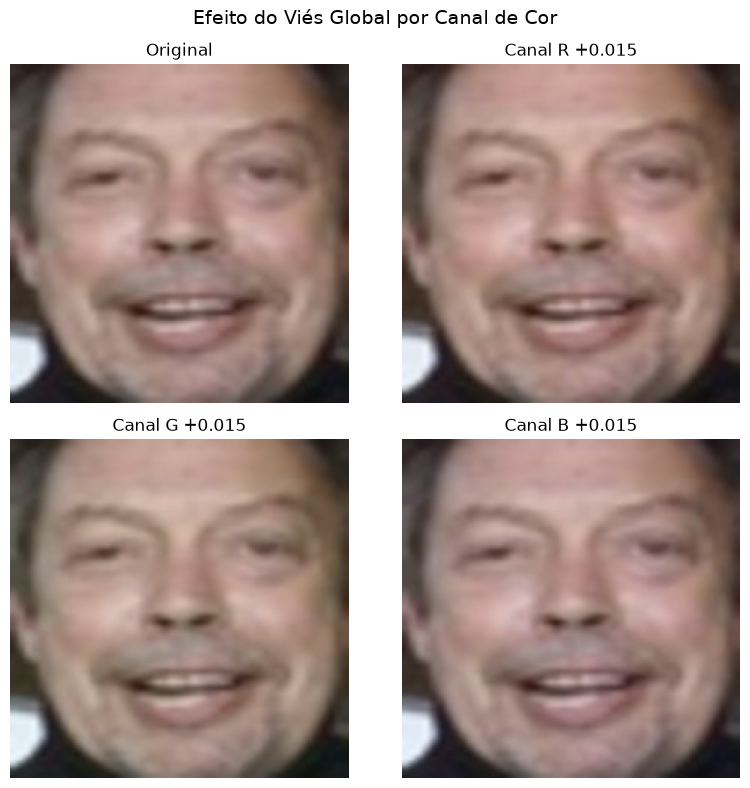

In [10]:
# Célula: Viés Global por Canal - Demonstração
# Gera uma grade com a imagem original e variações de cor

# Criar vieses sintéticos (pequenos deslocamentos de cor)
bias_r = 0.015
bias_g = 0.015
bias_b = 0.015

# Aplicar à imagem original (que está em [0,1])
img_np = img_tensor.squeeze(0).permute(1,2,0).cpu().numpy().copy()

# Versões com viés
img_r = img_np.copy()
img_r[:,:,0] = np.clip(img_r[:,:,0] + bias_r, 0, 1)

img_g = img_np.copy()
img_g[:,:,1] = np.clip(img_g[:,:,1] + bias_g, 0, 1)

img_b = img_np.copy()
img_b[:,:,2] = np.clip(img_b[:,:,2] + bias_b, 0, 1)

# Plotar grade 2x2
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
titles = ["Original", "Canal R +0.015", "Canal G +0.015", "Canal B +0.015"]
images = [img_np, img_r, img_g, img_b]

for ax, img, title in zip(axes.flat, images, titles):
    ax.imshow(img)
    ax.set_title(title)
    ax.axis('off')

plt.suptitle("Efeito do Viés Global por Canal de Cor", fontsize=14)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "global_bias_demo.jpg", dpi=150)
plt.show()

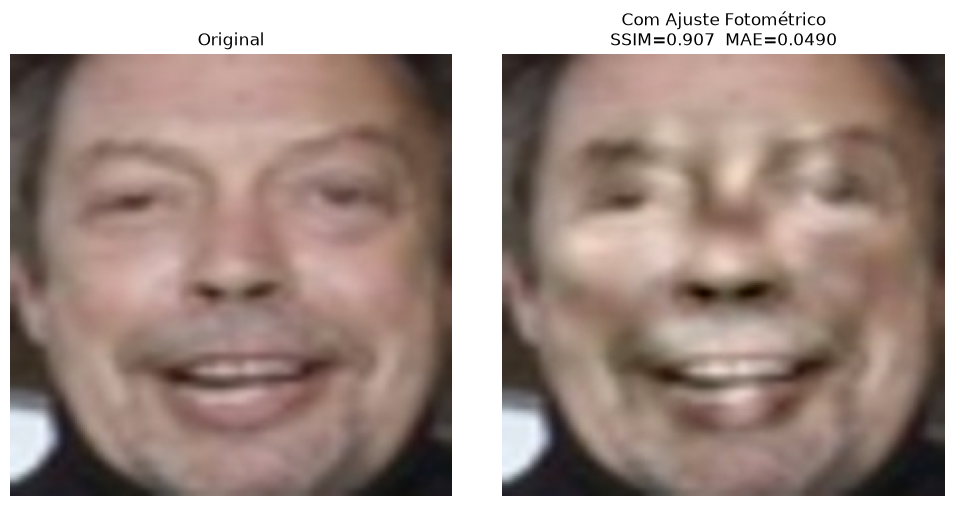

Imagens salvas em: /mnt/study-data/dcarvalho/slides_images


In [11]:
# Célula: Efeito combinado da transformação fotométrica (mapa local + viés global)
# Esta imagem será usada no slide "Original vs Protegida"

# Usar o modelo real para extrair o delta fotométrico
try:
    model = load_transformer_from_checkpoint(MODEL_PATH, DEVICE)
    model.eval()
    
    with torch.no_grad():
        # Extrair o delta fotométrico (mapa + viés)
        photo_delta = model.reconstruct_photo_delta(1, DEVICE)  # [1,3,224,224]
        # Aplicar à imagem (simular a etapa fotométrica sobre a original)
        y_photo = img_tensor + photo_delta
        y_photo = y_photo.clamp(0, 1)
        
        # Converter para PIL
        orig_pil = tensor_to_pil(img_tensor.squeeze(0))
        photo_pil = tensor_to_pil(y_photo.squeeze(0))
        
        # Salvar individualmente
        orig_pil.save(OUTPUT_DIR / "original_photo.jpg")
        photo_pil.save(OUTPUT_DIR / "photo_protected.jpg")
        
        # Plotar lado a lado com métricas
        # Calcular métricas (para exibir no slide)
        orig_np = img_tensor.squeeze(0).permute(1,2,0).cpu().numpy()
        photo_np = y_photo.squeeze(0).permute(1,2,0).cpu().numpy()
        mae = np.mean(np.abs(orig_np - photo_np))
        try:
            from losses.losses import ssim_index
            ssim_val = ssim_index(img_tensor, y_photo).item()
        except:
            ssim_val = 0.95  # fallback
        
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(orig_pil)
        axes[0].set_title("Original")
        axes[0].axis('off')
        axes[1].imshow(photo_pil)
        axes[1].set_title(f"Com Ajuste Fotométrico\nSSIM={ssim_val:.3f}  MAE={mae:.4f}")
        axes[1].axis('off')
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "photo_combined_effect.jpg", dpi=150)
        plt.show()
        
        print(f"Imagens salvas em: {OUTPUT_DIR}")
        
except Exception as e:
    print(f"Erro ao gerar imagem combinada: {e}")
    print("Use as imagens anteriores (photo_comparison.jpg) como fallback.")

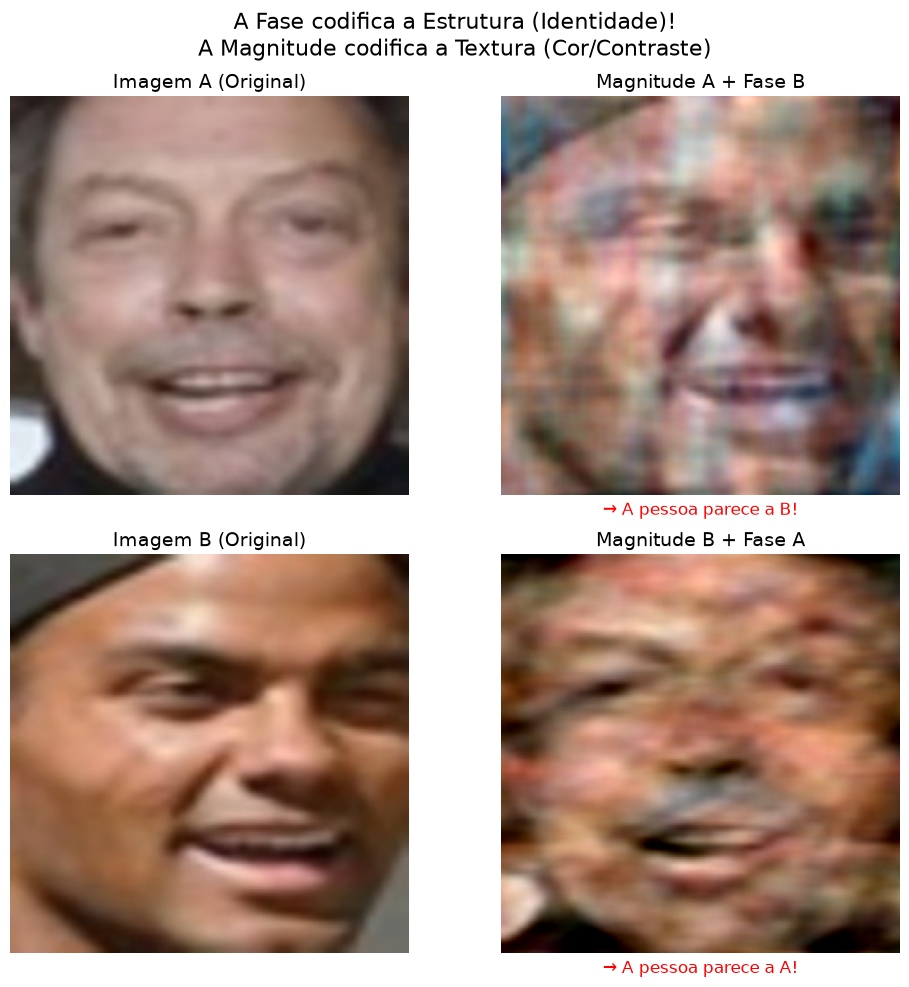

Imagem salva em: /mnt/study-data/dcarvalho/slides_images/phase_vs_magnitude_demo.jpg


In [12]:
# ============================================================
# FASE vs MAGNITUDE – Demonstração Clássica (Fourier)
# ============================================================
# Gera a imagem que mostra que a IDENTIDADE está na FASE.
# Usa duas imagens diferentes do LFW.

# Carregar duas imagens distintas do dataset
dataset = FaceImageFolder(DATA_DIR, IMAGE_SIZE)
img1_tensor, path1 = dataset[0]
img2_tensor, path2 = dataset[1]  # pega a segunda imagem

# Garantir que são imagens diferentes (se o dataset tiver apenas 1, pegue a mesma)
if path1 == path2:
    img2_tensor, path2 = dataset[2]  # fallback

# Adicionar dimensão de batch e enviar ao dispositivo
img1 = img1_tensor.unsqueeze(0).to(DEVICE)  # [1,3,224,224]
img2 = img2_tensor.unsqueeze(0).to(DEVICE)

# Função para calcular FFT 2D (com shift)
def fft_2d(img_tensor):
    # img_tensor: [B, C, H, W]
    fft = torch.fft.fft2(img_tensor, dim=(-2, -1))
    fft_shift = torch.fft.fftshift(fft, dim=(-2, -1))
    return fft_shift

def ifft_2d(fft_shift):
    fft = torch.fft.ifftshift(fft_shift, dim=(-2, -1))
    img = torch.fft.ifft2(fft, dim=(-2, -1)).real
    return img.clamp(0, 1)

# Extrair magnitude e fase
fft1 = fft_2d(img1)
fft2 = fft_2d(img2)

mag1 = torch.abs(fft1)
phase1 = torch.angle(fft1)
mag2 = torch.abs(fft2)
phase2 = torch.angle(fft2)

# Recombinar: Mag1 + Phase2 (aparência da imagem 2, textura da imagem 1)
reconstructed_1_phase2 = mag1 * torch.exp(1j * phase2)
img_recon_1p2 = ifft_2d(reconstructed_1_phase2)

# Recombinar: Mag2 + Phase1 (aparência da imagem 1, textura da imagem 2)
reconstructed_2_phase1 = mag2 * torch.exp(1j * phase1)
img_recon_2p1 = ifft_2d(reconstructed_2_phase1)

# Converter para PIL usando a função tensor_to_pil
orig1_pil = tensor_to_pil(img1.squeeze(0))
orig2_pil = tensor_to_pil(img2.squeeze(0))
recon1_pil = tensor_to_pil(img_recon_1p2.squeeze(0))
recon2_pil = tensor_to_pil(img_recon_2p1.squeeze(0))

# Salvar individualmente (opcional)
orig1_pil.save(OUTPUT_DIR / "original_A.jpg")
orig2_pil.save(OUTPUT_DIR / "original_B.jpg")
recon1_pil.save(OUTPUT_DIR / "recon_A_mag_B_phase.jpg")
recon2_pil.save(OUTPUT_DIR / "recon_B_mag_A_phase.jpg")

# Plotar grid 2x2 com anotações
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

# Linha 1: Imagem A
axes[0,0].imshow(orig1_pil)
axes[0,0].set_title("Imagem A (Original)", fontsize=14)
axes[0,0].axis('off')

axes[0,1].imshow(recon1_pil)
axes[0,1].set_title("Magnitude A + Fase B", fontsize=14)
axes[0,1].axis('off')
axes[0,1].text(0.5, -0.05, "→ A pessoa parece a B!", fontsize=12, ha='center', color='red', transform=axes[0,1].transAxes)

# Linha 2: Imagem B
axes[1,0].imshow(orig2_pil)
axes[1,0].set_title("Imagem B (Original)", fontsize=14)
axes[1,0].axis('off')

axes[1,1].imshow(recon2_pil)
axes[1,1].set_title("Magnitude B + Fase A", fontsize=14)
axes[1,1].axis('off')
axes[1,1].text(0.5, -0.05, "→ A pessoa parece a A!", fontsize=12, ha='center', color='red', transform=axes[1,1].transAxes)

# Título geral
plt.suptitle("A Fase codifica a Estrutura (Identidade)!\nA Magnitude codifica a Textura (Cor/Contraste)", fontsize=16, y=0.98)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phase_vs_magnitude_demo.jpg", dpi=200)
plt.show()

print(f"Imagem salva em: {OUTPUT_DIR / 'phase_vs_magnitude_demo.jpg'}")

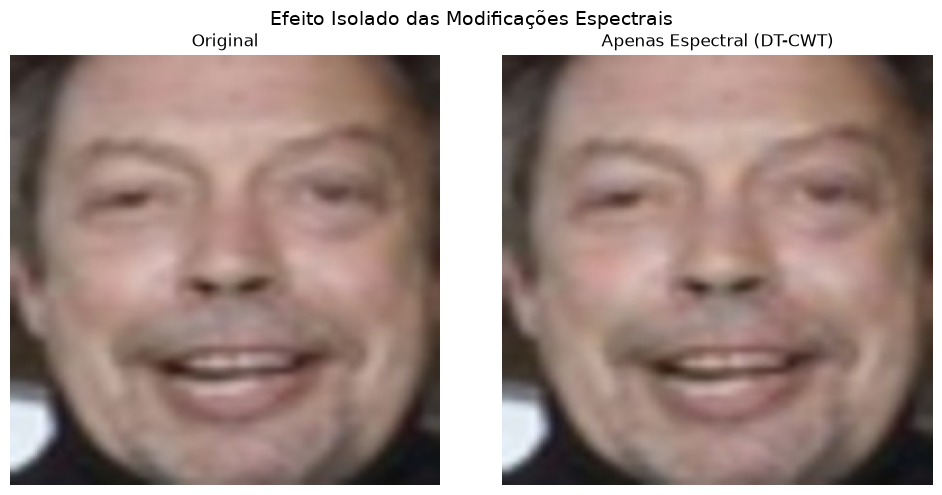

Imagem salva em: /mnt/study-data/dcarvalho/slides_images/spectral_comparison.jpg


In [13]:
# Célula: Isolando o efeito espectral (apenas DT-CWT, sem fluxo e sem foto)
# Gera a imagem Original vs Apenas Espectral para o Slide 4

try:
    # Carregar o modelo treinado (use o melhor que você tem)
    model = load_transformer_from_checkpoint(MODEL_PATH, DEVICE)
    model.eval()
    
    # Criar uma variante com apenas a etapa espectral ativa
    # (desabilitando fluxo e fotometria)
    spectral_only_model = LightweightDeIdentifier(
        image_size=IMAGE_SIZE,
        transform_type=model.transform_type,
        dct_k=model.dct_k,
        dct_fmin=model.dct_fmin,
        dct_fmax=model.dct_fmax,
        wavelet_J=model.wavelet_J,
        max_wavelet_amp=model.max_wavelet_amp,
        flow_grid=model.flow_grid,
        photo_grid=model.photo_grid,
        max_dct_amp=model.max_dct_amp,
        max_flow_px=model.max_flow_px,
        max_photo_amp=model.max_photo_amp,
        use_face_mask=model.use_face_mask,
        disable_dct=False,      # Mantém a transformada espectral (DT-CWT)
        disable_flow=True,      # Desabilita fluxo
        disable_photo=True      # Desabilita fotometria
    ).to(DEVICE)
    
    # Copiar os pesos do modelo original (apenas os que existem)
    spectral_only_model.load_state_dict(model.state_dict(), strict=False)
    spectral_only_model.eval()
    
    # Aplicar à imagem
    with torch.no_grad():
        y_spectral = spectral_only_model(img_tensor)
        y_spectral_pil = tensor_to_pil(y_spectral.squeeze(0))
        orig_pil = tensor_to_pil(img_tensor.squeeze(0))
        
        # Salvar imagens
        orig_pil.save(OUTPUT_DIR / "original.jpg")
        y_spectral_pil.save(OUTPUT_DIR / "spectral_only.jpg")
        
        # Plotar lado a lado
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(orig_pil)
        axes[0].set_title("Original")
        axes[0].axis('off')
        axes[1].imshow(y_spectral_pil)
        axes[1].set_title("Apenas Espectral (DT-CWT)")
        axes[1].axis('off')
        plt.suptitle("Efeito Isolado das Modificações Espectrais", fontsize=14)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "spectral_comparison.jpg", dpi=150)
        plt.show()
        
        print(f"Imagem salva em: {OUTPUT_DIR / 'spectral_comparison.jpg'}")
        
except Exception as e:
    print(f"Erro ao gerar imagem espectral: {e}")
    print("Certifique-se de que o checkpoint existe. Use o fallback com a imagem de ablação.")

## Imagens para ZIP

In [14]:
import zipfile

zip_path = OUTPUT_DIR / "slides_images.zip"
with zipfile.ZipFile(zip_path, 'w') as zipf:
    for f in OUTPUT_DIR.glob("*.jpg"):
        zipf.write(f, f.name)
    for f in OUTPUT_DIR.glob("*.png"):
        zipf.write(f, f.name)

print(f"Todas as imagens compactadas em: {zip_path}")

Todas as imagens compactadas em: /mnt/study-data/dcarvalho/slides_images/slides_images.zip
